In [1]:
import os
import numpy as np
from matplotlib import pyplot as plt
import rasterio

In [2]:
base = 'tiles'
tiles = {}
for fn in os.listdir(base):
    if not fn.startswith('lidar'): continue
    osgrid = fn[-6:]
    with rasterio.open(os.path.join(base, fn, f'{osgrid}_DTM_1m.tif')) as tile:
        data = tile.read(1)
        bounds = tile.bounds
        tiles[osgrid] = {'data': data, 'bounds': bounds}
    print(f'Loaded {fn} with shape {tiles[osgrid]["data"].shape} and bounds {tiles[osgrid]["bounds"]}')

Loaded lidar_composite_dtm-2022-1-SD68ne with shape (5000, 5000) and bounds BoundingBox(left=365000.0, bottom=485000.0, right=370000.0, top=490000.0)
Loaded lidar_composite_dtm-2022-1-SD78nw with shape (5000, 5000) and bounds BoundingBox(left=370000.0, bottom=485000.0, right=375000.0, top=490000.0)
Loaded lidar_composite_dtm-2022-1-SD78ne with shape (5000, 5000) and bounds BoundingBox(left=375000.0, bottom=485000.0, right=380000.0, top=490000.0)
Loaded lidar_composite_dtm-2022-1-SD79sw with shape (5000, 5000) and bounds BoundingBox(left=370000.0, bottom=490000.0, right=375000.0, top=495000.0)
Loaded lidar_composite_dtm-2022-1-SD79se with shape (5000, 5000) and bounds BoundingBox(left=375000.0, bottom=490000.0, right=380000.0, top=495000.0)
Loaded lidar_composite_dtm-2022-1-SD69se with shape (5000, 5000) and bounds BoundingBox(left=365000.0, bottom=490000.0, right=370000.0, top=495000.0)
Loaded lidar_composite_dtm-2022-1-SD78sw with shape (5000, 5000) and bounds BoundingBox(left=370000.

In [3]:
min_left = min(tile['bounds'].left for tile in tiles.values())
min_bottom = min(tile['bounds'].bottom for tile in tiles.values())
max_right = max(tile['bounds'].right for tile in tiles.values())
max_top = max(tile['bounds'].top for tile in tiles.values())
array = np.empty((int(max_top - min_bottom), int(max_right - min_left)), dtype=np.float32)

for osgrid, tile in tiles.items():
    left = int(tile['bounds'].left - min_left)
    bottom = int(tile['bounds'].bottom - min_bottom)
    right = left + tile['data'].shape[1]
    top = bottom + tile['data'].shape[0]
    array[bottom:top, left:right] = tile['data'][::-1]

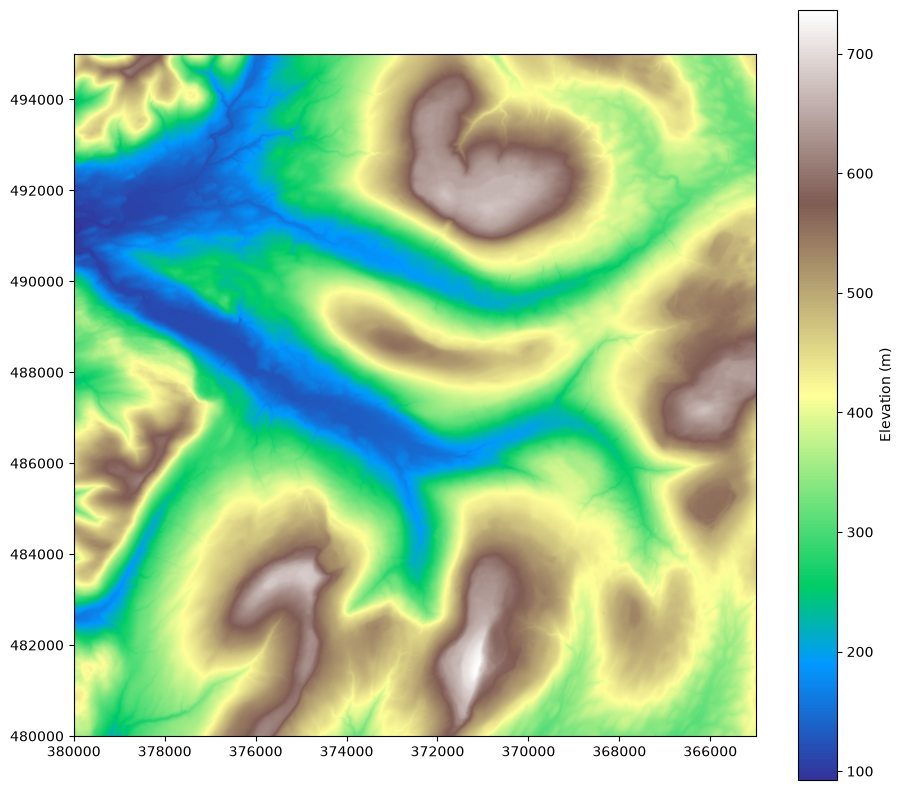

In [4]:
plt.figure(figsize=(11, 10))
plt.imshow(array[::-10,::10], extent=[max_right, min_left, min_bottom, max_top], cmap='terrain')
plt.colorbar(label='Elevation (m)')
plt.show()